In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/bhavikjikadara/student-study-performance/study_performance.csv


In [2]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [3]:
data = {
    "Maths": [78, 45, 96, 88, 67, 54, 89, 76],
    "English": [72, 55, 91, 85, 60, 58, 94, 70],
    "Attendance": [80, 60, 95, 90, 70, 65, 92, 75],
    "Final_Score": [75, 50, 95, 87, 65, 57, 93, 72]
}

df = pd.DataFrame(data)
df

,Maths,English,Attendance,Final_Score
0,78,72,80,75
1,45,55,60,50
2,96,91,95,95
3,88,85,90,87
4,67,60,70,65
5,54,58,65,57
6,89,94,92,93
7,76,70,75,72


In [4]:
X = df[["Maths", "English", "Attendance"]]
y = df["Final_Score"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [7]:
predictions = model.predict(X_test)
print(predictions)

[53.05205208 58.34514339]


In [8]:
mse = mean_squared_error(y_test, predictions)
print("Mean Squared Error:", mse)

Mean Squared Error: 5.562216329546262


In [9]:
df = pd.read_csv("/kaggle/input/datasets/bhavikjikadara/student-study-performance/study_performance.csv")
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [10]:
df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='object')

In [11]:
X = df[["reading_score", "writing_score"]]
y = df["math_score"]

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

mse = mean_squared_error(y_test, predictions)
print("Mean Squared Error:", mse)

Mean Squared Error: 77.24297821278955


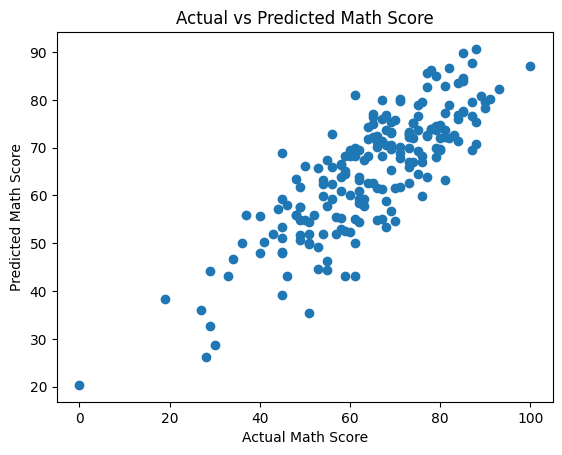

In [12]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions)
plt.xlabel("Actual Math Score")
plt.ylabel("Predicted Math Score")
plt.title("Actual vs Predicted Math Score")
plt.show()

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Load dataset
df = pd.read_csv("/kaggle/input/datasets/bhavikjikadara/student-study-performance/study_performance.csv")

# Features and Target
X = df.drop("math_score", axis=1)
y = df["math_score"]

# Categorical and Numeric columns
categorical_cols = ["gender", "race_ethnicity", "parental_level_of_education", "lunch", "test_preparation_course"]
numeric_cols = ["reading_score", "writing_score"]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

# Pipeline
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)

MSE: 29.09516986671551
RMSE: 5.393993869732845


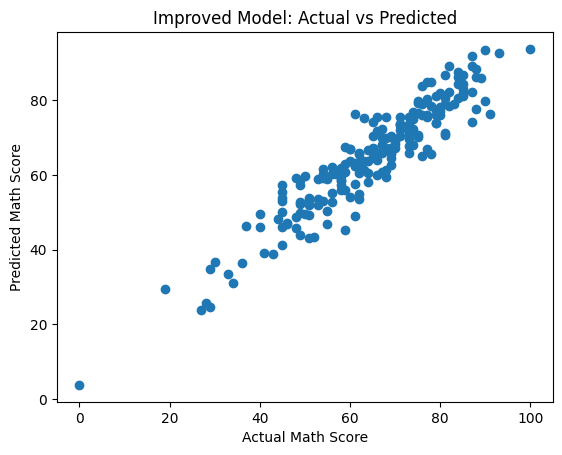

In [14]:
plt.scatter(y_test, predictions)
plt.xlabel("Actual Math Score")
plt.ylabel("Predicted Math Score")
plt.title("Improved Model: Actual vs Predicted")
plt.show()